In [1]:
from pathlib import Path
import pandas as pd
import torch
import matplotlib.pyplot as plt
import xarray as xr
import yaml
import geopandas as gpd
import numpy as np
import pickle
import itertools

In [2]:
# --------------------- Paths -------------------
ensemble_metrics_dir = Path("../all_ensemble_metrics")

In [3]:
# -------------------- NSE data for Uruguay basins (runs just with UY basins) -------------------
precip_products = [
    "prcp_mm_day",
    "prcp_chirps_mm_day",
    "prcp_mswep_mm_day",
    "prcp_gauge_mm_day",
]

all_combinations = [
    combo
    for r in range(1, len(precip_products) + 1)
    for combo in itertools.combinations(precip_products, r)
]

# all_combinations

In [4]:
metric_names = [
    'FHV', 'FMS', 'FLV',
    'Peak-Timing', 'Missed-Peaks', 'Peak-MAPE'
]

In [5]:
# Dict of {metric: list of arrays (one per combo)}
all_metrics = {m: [] for m in metric_names}
model_labels = {}
basins_order = []

for i, combo in enumerate(all_combinations, start=1):
    precip_name = "_".join(combo)
    metrics_csv = pd.read_csv(ensemble_metrics_dir / f"precip_{precip_name}.csv")

    if i == 1:
        basins_order = metrics_csv["basin_id"].values

    for metric in metric_names:
        all_metrics[metric].append(metrics_csv[metric].values)

    model_labels[i] = precip_name

In [6]:
model_labels

{1: 'prcp_mm_day',
 2: 'prcp_chirps_mm_day',
 3: 'prcp_mswep_mm_day',
 4: 'prcp_gauge_mm_day',
 5: 'prcp_mm_day_prcp_chirps_mm_day',
 6: 'prcp_mm_day_prcp_mswep_mm_day',
 7: 'prcp_mm_day_prcp_gauge_mm_day',
 8: 'prcp_chirps_mm_day_prcp_mswep_mm_day',
 9: 'prcp_chirps_mm_day_prcp_gauge_mm_day',
 10: 'prcp_mswep_mm_day_prcp_gauge_mm_day',
 11: 'prcp_mm_day_prcp_chirps_mm_day_prcp_mswep_mm_day',
 12: 'prcp_mm_day_prcp_chirps_mm_day_prcp_gauge_mm_day',
 13: 'prcp_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day',
 14: 'prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day',
 15: 'prcp_mm_day_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day'}

In [7]:
dataset_labels = [
    "CARAVAN",
    "CHIRPS",
    "MSWEP",
    "GAUGE",
    "CARAVAN\nCHIRPS",
    "CARAVAN\nMSWEP",
    "CARAVAN\nGAUGE",
    "CHIRPS\nMSWEP",
    "CHIRPS\nGAUGE",
    "MSWEP\nGAUGE",
    "CARAVAN\nCHIRPS\nMSWEP",
    "CARAVAN\nCHIRPS\nGAUGE",
    "CARAVAN\nMSWEP\nGAUGE",
    "CHIRPS\nMSWEP\nGAUGE",
    "CARAVAN\nCHIRPS\nMSWEP\nGAUGE"
]

/tmp/ipykernel_19573/2483274991.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(all_metrics[metric], labels=dataset_labels)


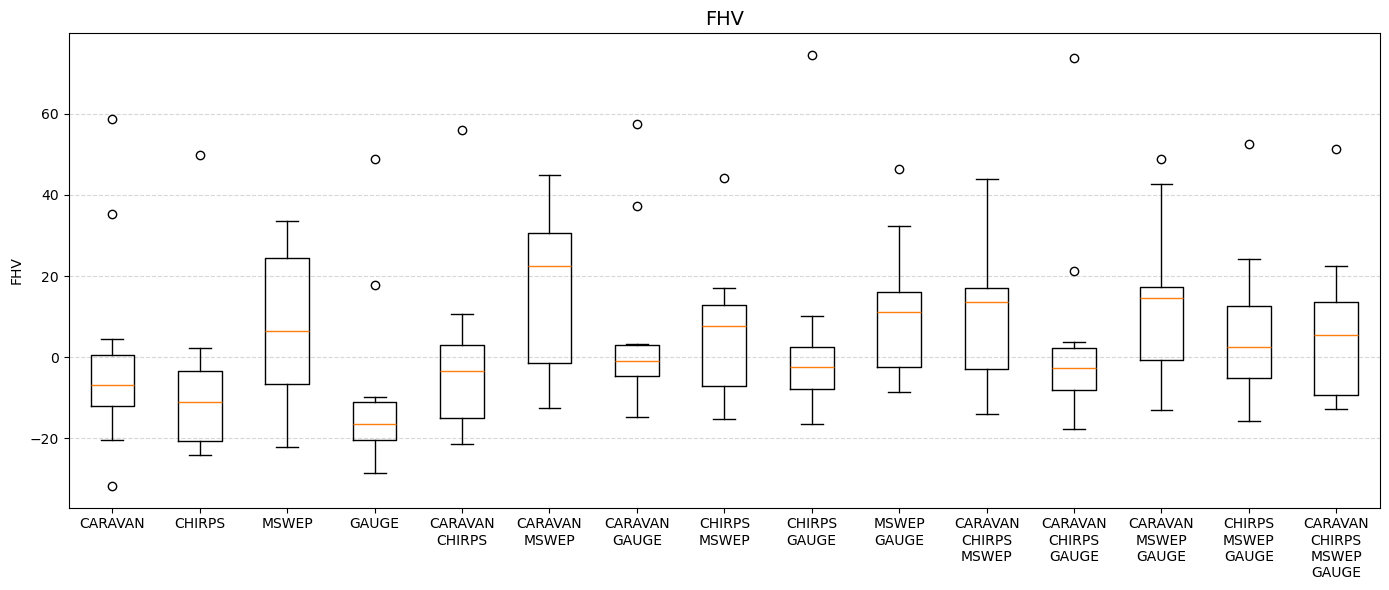

/tmp/ipykernel_19573/2483274991.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(all_metrics[metric], labels=dataset_labels)


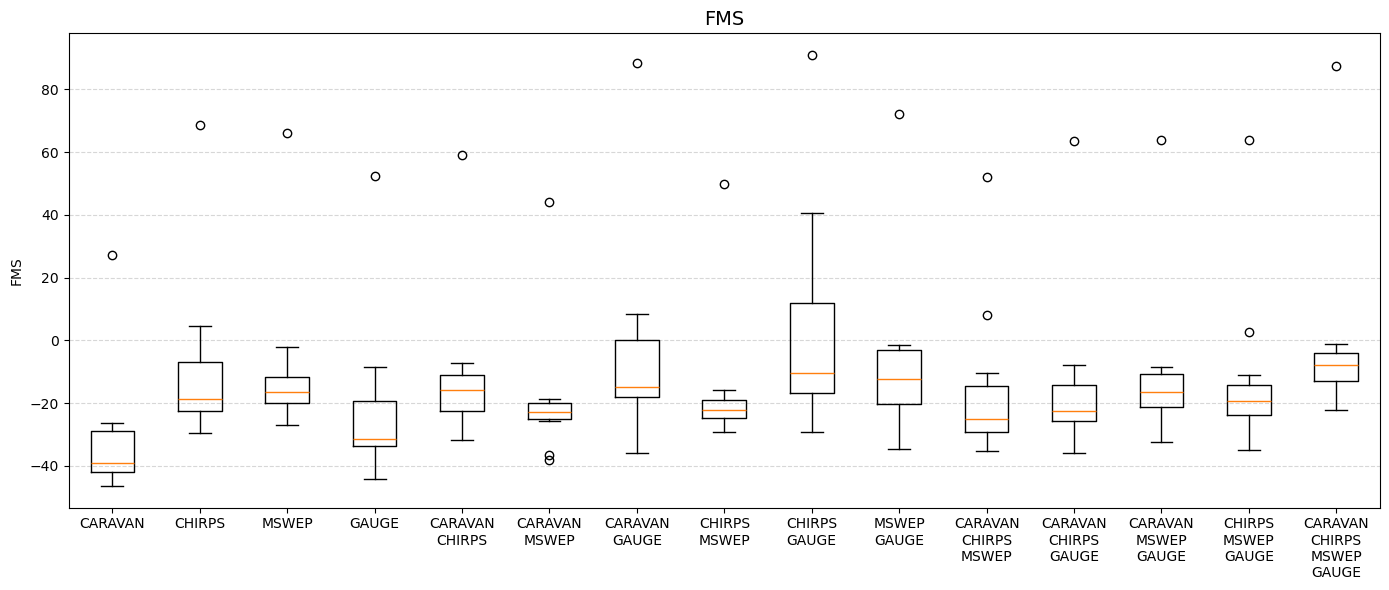

/tmp/ipykernel_19573/2483274991.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(all_metrics[metric], labels=dataset_labels)


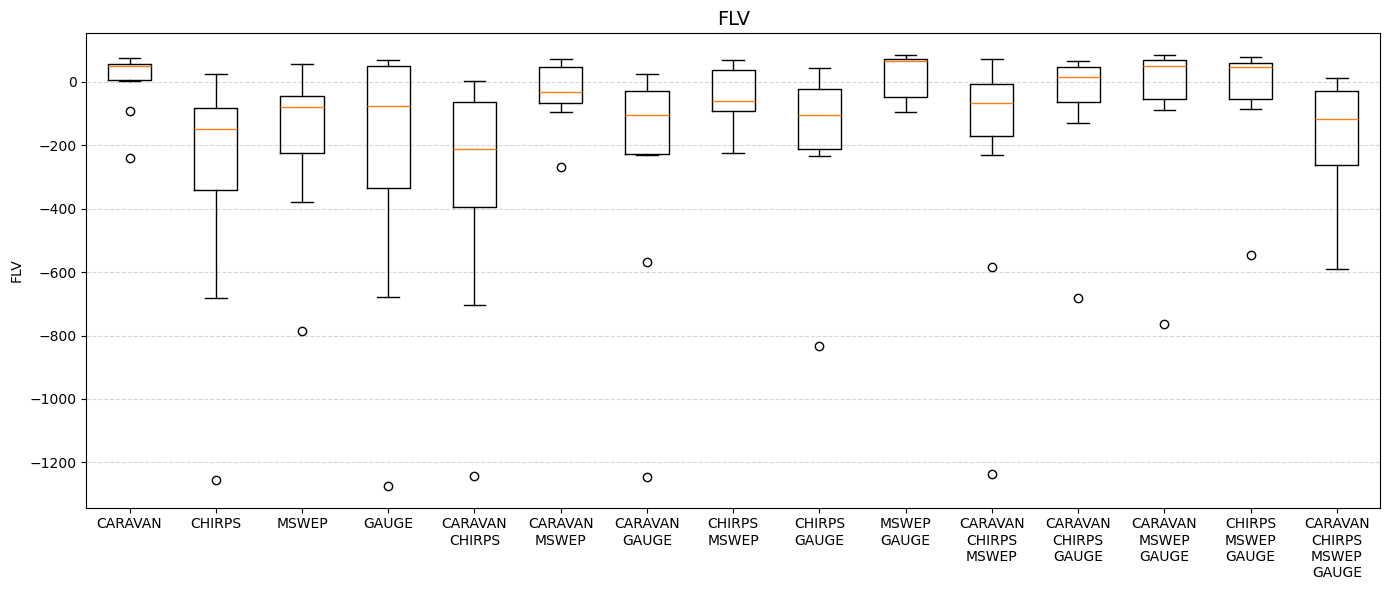

/tmp/ipykernel_19573/2483274991.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(all_metrics[metric], labels=dataset_labels)


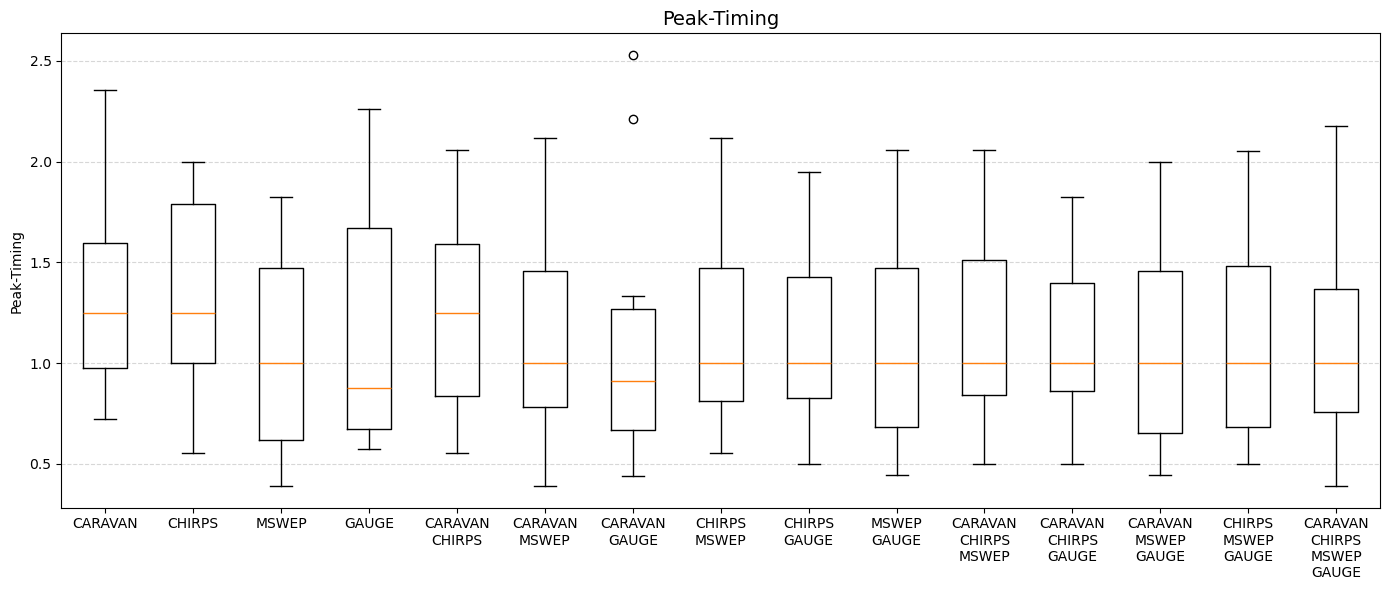

/tmp/ipykernel_19573/2483274991.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(all_metrics[metric], labels=dataset_labels)


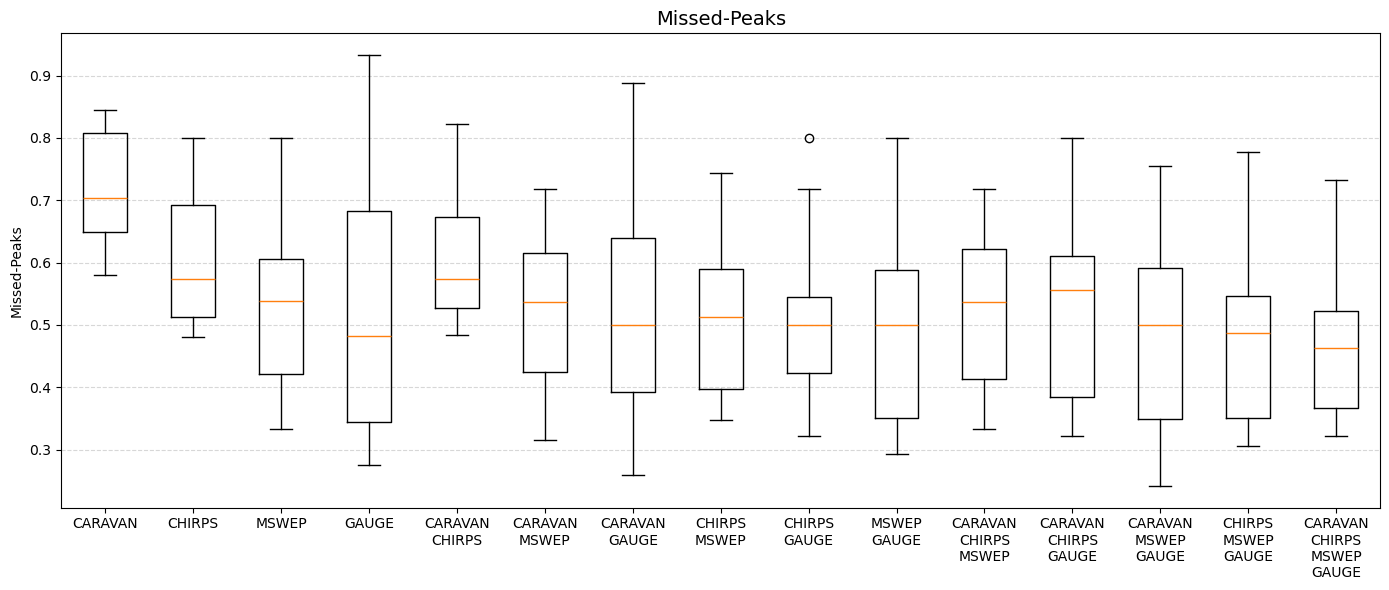

/tmp/ipykernel_19573/2483274991.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(all_metrics[metric], labels=dataset_labels)


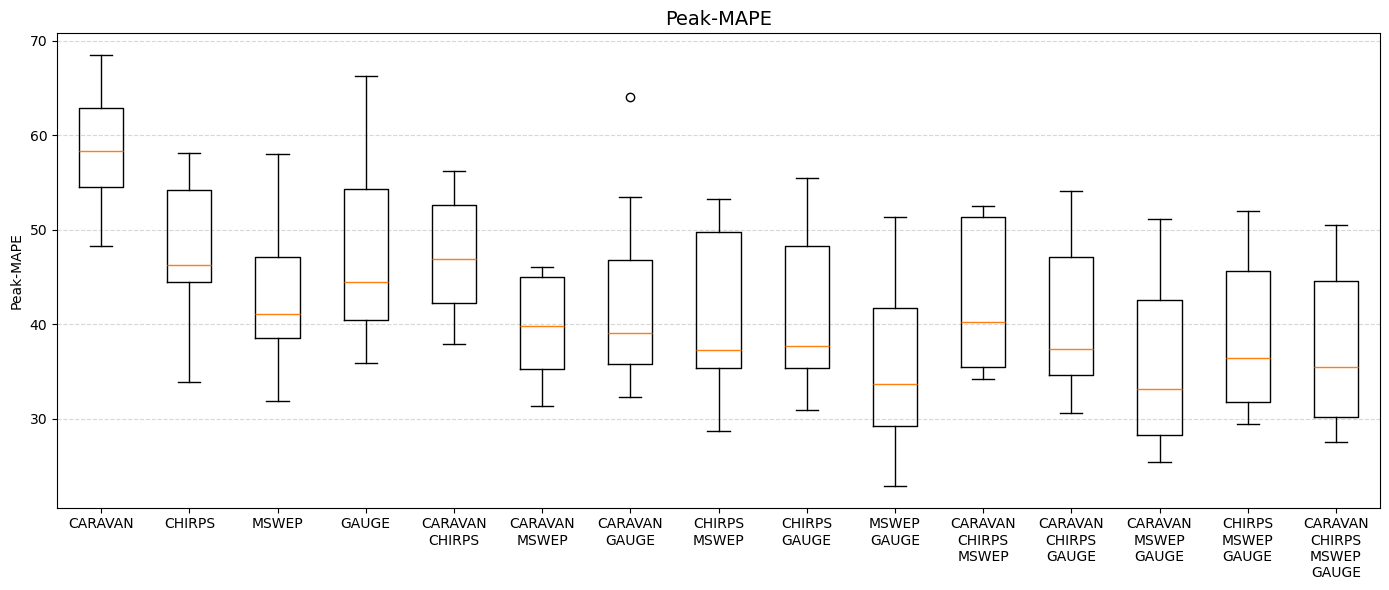

In [8]:
for metric in metric_names:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    ax.boxplot(all_metrics[metric], labels=dataset_labels)
    ax.set_title(metric, fontsize=14)
    # ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel(metric)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    # plt.savefig(ensemble_metrics_dir / f"boxplot_{metric}.png", dpi=150, bbox_inches='tight')
    plt.show()

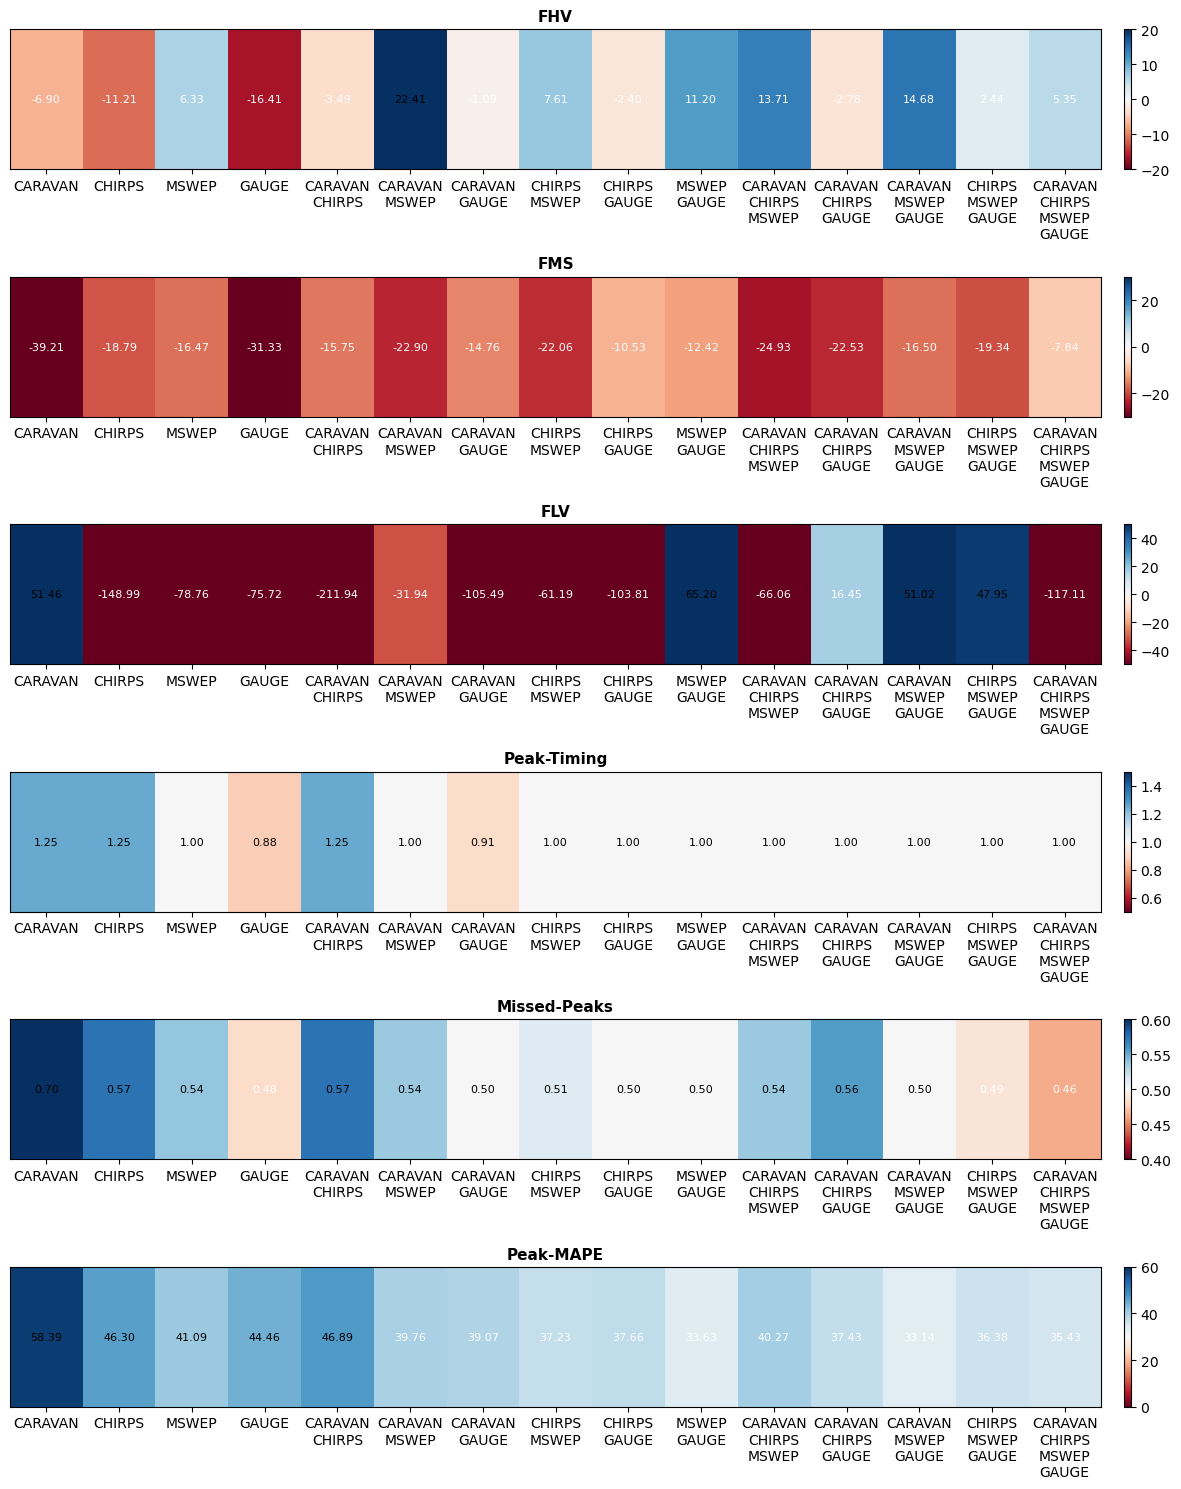

In [9]:
metric_limits = {
    'FHV':          (-20, 20),
    'FMS':          (-30, 30),
    'FLV':          (-50, 50),
    'Peak-Timing':  (0.5,   1.5),
    'Missed-Peaks': (0.4, 0.6),
    'Peak-MAPE':    (0, 60),
}

fig, axes = plt.subplots(len(metric_names), 1, figsize=(12, 15))

for ax, metric in zip(axes, metric_names):
    medians = np.array([np.nanmedian(values) for values in all_metrics[metric]])
    data_2d = medians.reshape(1, -1)
    
    vmin, vmax = metric_limits[metric]
    im = ax.imshow(data_2d, aspect='auto', cmap='RdBu', vmin=vmin, vmax=vmax)
    
    plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
    
    for j, val in enumerate(medians):
        ax.text(j, 0, f"{val:.2f}", ha='center', va='center', fontsize=8,
                color='white' if val < np.nanmax(medians) * 0.7 else 'black')
    
    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.set_yticks([])
    ax.set_xticks(range(len(dataset_labels)))
    ax.set_xticklabels(dataset_labels) #, fontsize=8, rotation=45, ha='right')

plt.tight_layout()
plt.savefig(ensemble_metrics_dir / "heatmap_median_metrics.png", dpi=150, bbox_inches='tight')
plt.show()